**Assignment**
### Santiago López Sánchez
1. Remember to add your name to the title of the notebook
2. The goal is to explore models that underfit and overfit, and to deal with overfitting by using the techniques seen in class.


In [1]:
# Import needed libraries
import numpy as np
import sys, os, pdb
import pandas as pd
from matplotlib import pyplot as plt


Data:

Consists of the gene expression profile of several cells (coming from a patient).

There is a train and a test datasets already provided to you.

They are organized as a matrix of cells x genes.

Given a cell, the goal is to predict the correct cell-type based on the genes' expressions for that sample.

In [2]:
# Link your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load data

# Path to source batch
train_path = "/content/drive/MyDrive/Deep Learning/HW1DL_Idoia/train.pkl"
# Path to target batch
test_path = "/content/drive/MyDrive/Deep Learning/HW1DL_Idoia/test.pkl"
# Column containing cell-types
lname = "labels"

train_batch = pd.read_pickle(train_path)
test_batch = pd.read_pickle(test_path)

In [4]:
train_batch

index,HES4,ISG15,TNFRSF18,TNFRSF4,MMP23B,UTS2,TNFRSF9,RBP7,PGD,AGTRAP,...,AP000692.10,BACE2,MX1,AP001059.6,AIRE,COL6A2,S100B,MT-ATP8,MT-ND6,labels
index,,,,,,,,,,,,,,,,,,,,,
data_3p-AAACCTGAGCATCATC-0,-0.196407,2.163650,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,-0.410718,-0.578313,-0.609471,...,-0.100605,-0.169544,3.396856,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,B cell
data_3p-AAACCTGAGCTAGTGG-0,-0.196407,1.371853,-0.186414,8.028668,-0.130663,-0.079505,-0.089647,-0.410718,1.221355,-0.609471,...,-0.100605,-0.169544,-0.382577,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,CD4 T cell
data_3p-AAACCTGCACATTAGC-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,-0.410718,1.770606,-0.609471,...,-0.100605,-0.169544,-0.382577,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,0.840558,CD4 T cell
data_3p-AAACCTGCACTGTTAG-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,2.437211,-0.578313,1.062532,...,-0.100605,-0.169544,-0.382577,8.922243,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,Monocyte_CD14
data_3p-AAACCTGCATAGTAAG-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,1.606579,-0.578313,1.112563,...,-0.100605,-0.169544,-0.382577,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,Monocyte_CD14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
data_3p-TTTGTCATCATGTCCC-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,-0.410718,-0.578313,-0.609471,...,-0.100605,-0.169544,-0.382577,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,CD8 T cell
data_3p-TTTGTCATCCGATATG-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,-0.410718,-0.578313,-0.609471,...,-0.100605,-0.169544,2.025987,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,0.335671,CD8 T cell
data_3p-TTTGTCATCGTCTGAA-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,1.252710,0.921344,-0.609471,...,-0.100605,-0.169544,-0.382577,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,Monocyte_CD14


In [5]:
# Extract the common genes so that we can use the same network for both batches

common_genes = list(set(train_batch.columns).intersection(set(test_batch.columns)))
common_genes.sort()
train_batch = train_batch[list(common_genes)]
test_batch = test_batch[list(common_genes)]

train_mat = train_batch.drop(lname, axis=1)
train_labels = train_batch[lname]

test_mat = test_batch.drop(lname, axis=1)
test_labels = test_batch[lname]

# values are already normalized (ignore this)
mat = train_mat.values
mat_round = np.rint(mat)
error = np.mean(np.abs(mat - mat_round))


In [6]:
train_labels.unique()

['B cell', 'CD4 T cell', 'Monocyte_CD14', 'CD8 T cell', 'Monocyte_FCGR3A', 'NK cell', 'Megakaryocyte', 'Plasmacytoid dendritic cell', 'Hematopoietic stem cell']
Categories (9, object): ['B cell', 'CD4 T cell', 'CD8 T cell', 'Hematopoietic stem cell', ...,
                         'Monocyte_CD14', 'Monocyte_FCGR3A', 'NK cell',
                         'Plasmacytoid dendritic cell']

Q1: What type of problem are you dealing with?

A multiclass classification

Q2: What is the size of the input, i.e., number of features?

8096 samples
1200 columns but labels should be deleted so there are 1199 features

Q3: How many neurons should you have in the last layer?

The same as categories we have so 9.

Q4: What is the most appropiate activation function to use in the last layer?

K neurons where K = 9 with a Softmax activation layer

In [7]:
from sklearn.preprocessing import OneHotEncoder

# Initialize the OneHotEncoder
# handle_unknown='ignore' allows the encoder to handle labels in the test set that might not be present in the training set
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit the encoder on the training labels and transform them
train_labels_encoded = encoder.fit_transform(train_labels.values.reshape(-1, 1))

# Transform the test labels
test_labels_encoded = encoder.transform(test_labels.values.reshape(-1, 1))

print("Shape of one-hot encoded training labels:", train_labels_encoded.shape)
print("Shape of one-hot encoded test labels:", test_labels_encoded.shape)

Shape of one-hot encoded training labels: (8098, 9)
Shape of one-hot encoded test labels: (7378, 9)


In [8]:
#Q5: How did you modify the labels?

#Transforming the labels with one hot encoding

#Q6: Which loss function are you going to use to train the networks?

#Cross-Entropy Loss

In [9]:
# Minimum number of things you should try:

#-

Things I woul like to see (at least):

- Without using any kind of regularization, train 3 networks: one that underfits the data, one that does OK, and one that overfits very easily.
-- Comment on why you think each network behaves in a specific way: e.g., number of parameters, number of layers, size of each layer...
-- Comment on the results you observe

- Deal with overfitting by using:
-- L1, L2 or combination of both
-- Dropout
-- Comment on the results: what works better, how you chose the regularization parameter or dropout rate, etc.

- Show the results on the test set of your "best" model.

- Provide some conclusions of the analysis you performed.


El One Hot Encoding no aprende parámetros estadísticos del conjunto de datos, simplemente asigna columnas a cada categoría. Por ello, no existe riesgo de data leakage ni dependencia entre train y test. Por tanto, en el caso de un one hot encoding de las etiquetas, no afecta si se separan los datos antes o después de codificarlos.

In [10]:
from sklearn.model_selection import train_test_split

X_test_final, X_val_from_test, y_test_final, y_val_from_test = train_test_split(
    test_mat,
    test_labels_encoded,
    test_size=0.3,       # por ejemplo usar el 30% de test para validation
    random_state=42,
    stratify=test_labels_encoded.argmax(axis=1)  # si quieres estratificar
)


First we will start with a small Network.

In [11]:
#Define the network
import keras
from keras import models
from keras import layers

small_model = keras.Sequential([
    layers.Dense(10, activation="relu"),
    layers.Dense(9, activation="softmax")
])

In [12]:
#Compile the model
small_model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy", # multiclase
              metrics=["accuracy"])

In [13]:
small_hist = small_model.fit(
    train_mat,
    train_labels_encoded,
    epochs=5,
    batch_size=512,
    validation_data=(X_val_from_test, y_val_from_test))

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3434 - loss: 1.7085 - val_accuracy: 0.4950 - val_loss: 1.3119
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8290 - loss: 0.6641 - val_accuracy: 0.6757 - val_loss: 0.9320
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8945 - loss: 0.3955 - val_accuracy: 0.7439 - val_loss: 0.7180
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9268 - loss: 0.2672 - val_accuracy: 0.7710 - val_loss: 0.6039
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9347 - loss: 0.2022 - val_accuracy: 0.8252 - val_loss: 0.4746


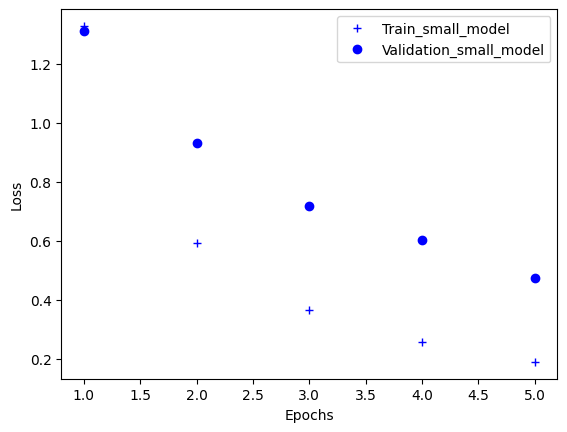

In [14]:
import matplotlib.pyplot as plt

epochs = range(1, 6)
train_loss = small_hist.history['loss']
smaller_model_val_loss = small_hist.history['val_loss']

# b+ is for "blue cross"
plt.plot(epochs, train_loss, 'b+', label='Train_small_model')
# "bo" is for "blue dot"
plt.plot(epochs, smaller_model_val_loss, 'bo', label='Validation_small_model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In the previous comparison of training loss and validation loss, we can observe that the model is improving. Therefore, we can consider using a larger model or training it for more epochs. This small Network doesnt perfoms bad but if we do the network bigger it will improve better

Let's try with a medium model with two hidden layers, with 64 and 32 neurons each layer respectively.

In [15]:
mid_model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(9, activation="softmax")
])

In [16]:
#Compile the model
mid_model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy", # multiclase
              metrics=["accuracy"])

In [17]:
mid_hist = mid_model.fit(
    train_mat,
    train_labels_encoded,
    epochs=8,
    batch_size=512,
    validation_data=(X_val_from_test, y_val_from_test))

Epoch 1/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5671 - loss: 1.2791 - val_accuracy: 0.8853 - val_loss: 0.5012
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9369 - loss: 0.2072 - val_accuracy: 0.9268 - val_loss: 0.3093
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9672 - loss: 0.1020 - val_accuracy: 0.9449 - val_loss: 0.2440
Epoch 4/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9859 - loss: 0.0517 - val_accuracy: 0.9476 - val_loss: 0.2231
Epoch 5/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9956 - loss: 0.0294 - val_accuracy: 0.9408 - val_loss: 0.2196
Epoch 6/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9898 - loss: 0.0313 - val_accuracy: 0.9499 - val_loss: 0.1880
Epoch 7/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9978 - loss: 0.0142 - val_accuracy: 0.9548 - val_loss: 0.1679
Epoch 8/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9957 - loss: 0.0134 - val_accuracy: 0.9562 - val_loss:

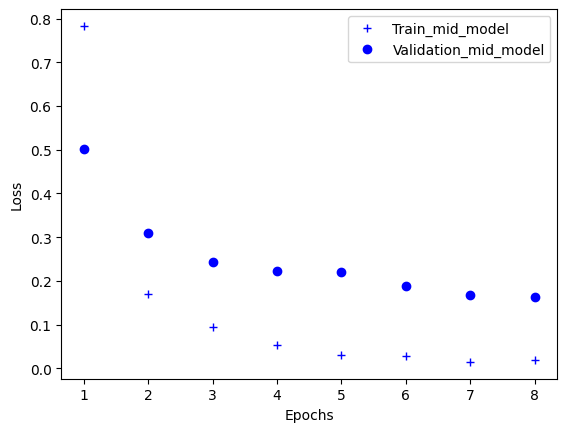

In [18]:
epochs = range(1, 9)
train_loss = mid_hist.history['loss']
mid_model_val_loss = mid_hist.history['val_loss']

# b+ is for "blue cross"
plt.plot(epochs, train_loss, 'b+', label='Train_mid_model')
# "bo" is for "blue dot"
plt.plot(epochs, mid_model_val_loss, 'bo', label='Validation_mid_model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

The problem seems to be quite easy to a deep learning model so, with more than 8 epochs with a medium model the network starts to overfit. We can say that with a medium model and 8 epochs of training the model performs OK.

Now let's try if with a larger model the model performs better.

In [19]:
bigger_model = keras.Sequential([
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(9, activation="softmax")
])

In [20]:
#Compile the model
bigger_model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy", # multiclase
              metrics=["accuracy"])

In [21]:
bigger_hist = bigger_model.fit(
    train_mat,
    train_labels_encoded,
    epochs=25,
    batch_size=512,
    validation_data=(X_val_from_test, y_val_from_test))

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5964 - loss: 1.1967 - val_accuracy: 0.9566 - val_loss: 0.2086
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9291 - loss: 0.1917 - val_accuracy: 0.9661 - val_loss: 0.1425
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9750 - loss: 0.0757 - val_accuracy: 0.9711 - val_loss: 0.1148
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9925 - loss: 0.0327 - val_accuracy: 0.9720 - val_loss: 0.1181
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9705 - loss: 0.0938 - val_accuracy: 0.9738 - val_loss: 0.1053
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9941 - loss: 0.0225 - val_accuracy: 0.9702 - val_loss: 0.1143
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9989 - loss: 0.0088 - val_accuracy: 0.9693 - val_loss: 0.1195
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9693 - v

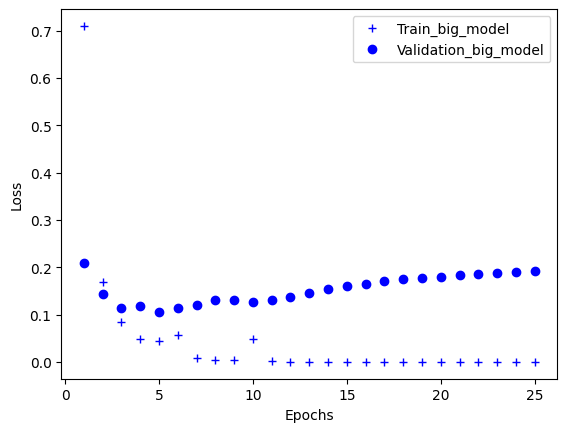

In [22]:
epochs = range(1, 26)
train_loss = bigger_hist.history['loss']
bigger_model_val_loss = bigger_hist.history['val_loss']

# b+ is for "blue cross"
plt.plot(epochs, train_loss, 'b+', label='Train_big_model')
# "bo" is for "blue dot"
plt.plot(epochs, bigger_model_val_loss, 'bo', label='Validation_big_model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

As we can see if we fit a big model to a problem that does not need it we will overfit the network. That means that the model fits to the training data and does not generalize on test data.

To deal with overfitting we can apply several techniques. One option is to use regularization methods, similar to those used in traditional machine learning, such as L1 or L2 penalties on the weights. Another widely used technique is dropout, which randomly deactivates a subset of neurons during training. By preventing all neurons from updating their weights at every step, dropout forces the network to learn more robust and generalized representations.

In [23]:
from keras import regularizers

#Same model but with regularization in every layer, let's see how perform's

bigger_model_l2 = keras.Sequential([
    layers.Dense(256, kernel_regularizer=regularizers.l2(0.001), activation="relu"),
    layers.Dense(128, kernel_regularizer=regularizers.l2(0.001), activation="relu"),
    layers.Dense(64, kernel_regularizer=regularizers.l2(0.001), activation="relu"),
    layers.Dense(32, kernel_regularizer=regularizers.l2(0.001), activation="relu"),
    layers.Dense(9, activation="softmax")
])

In [24]:
#Compile the model
bigger_model_l2.compile(optimizer="rmsprop",
              loss="categorical_crossentropy", # multiclase
              metrics=["accuracy"])

In [25]:
bigger_hist_l2 = bigger_model_l2.fit(
    train_mat,
    train_labels_encoded,
    epochs=25,
    batch_size=512,
    validation_data=(X_val_from_test, y_val_from_test))

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5758 - loss: 1.8426 - val_accuracy: 0.9336 - val_loss: 0.9930
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9521 - loss: 0.8365 - val_accuracy: 0.9684 - val_loss: 0.7907
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9750 - loss: 0.7094 - val_accuracy: 0.9634 - val_loss: 0.7281
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9906 - loss: 0.6056 - val_accuracy: 0.9630 - val_loss: 0.6658
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9965 - loss: 0.5372 - val_accuracy: 0.9724 - val_loss: 0.5884
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9863 - loss: 0.5123 - val_accuracy: 0.9679 - val_loss: 0.5525
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9984 - loss: 0.4348 - val_accuracy: 0.9575 - val_loss: 0.5287
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9999 - loss: 0.3886 - val_accuracy: 0.9706 - v

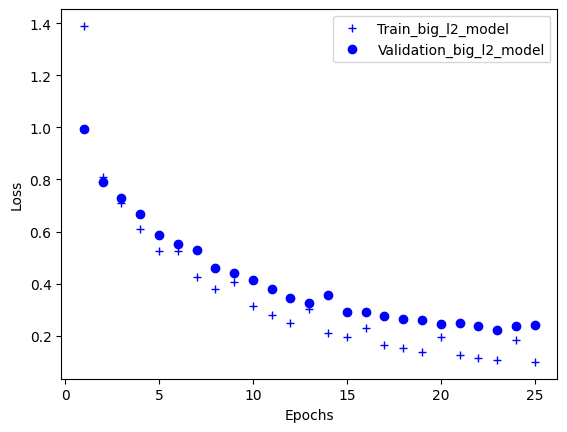

In [26]:
epochs = range(1, 26)
train_loss = bigger_hist_l2.history['loss']
bigger_model_l2_val_loss = bigger_hist_l2.history['val_loss']

# b+ is for "blue cross"
plt.plot(epochs, train_loss, 'b+', label='Train_big_l2_model')
# "bo" is for "blue dot"
plt.plot(epochs, bigger_model_l2_val_loss, 'bo', label='Validation_big_l2_model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

As we can see the model does not overfits and continues performing well with validation data.

Now lets try with dropout.

In [27]:
from keras import regularizers

#Same model but with regularization in every layer, let's see how perform's

bigger_model_drop = keras.Sequential([
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(9, activation="softmax")
])

In [28]:
#Compile the model
bigger_model_drop.compile(optimizer="rmsprop",
              loss="categorical_crossentropy", # multiclase
              metrics=["accuracy"])

In [29]:
bigger_hist_drop = bigger_model_drop.fit(
    train_mat,
    train_labels_encoded,
    epochs=25,
    batch_size=512,
    validation_data=(X_val_from_test, y_val_from_test))

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.3730 - loss: 1.7065 - val_accuracy: 0.9241 - val_loss: 0.4165
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7613 - loss: 0.6524 - val_accuracy: 0.9648 - val_loss: 0.1832
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8829 - loss: 0.3526 - val_accuracy: 0.9693 - val_loss: 0.1389
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9291 - loss: 0.2281 - val_accuracy: 0.9706 - val_loss: 0.1409
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9503 - loss: 0.1615 - val_accuracy: 0.9675 - val_loss: 0.1465
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9635 - loss: 0.1119 - val_accuracy: 0.9521 - val_loss: 0.2018
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9678 - loss: 0.1095 - val_accuracy: 0.9729 - val_loss: 0.1662
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9776 - loss: 0.0699 - val_accuracy: 0.9711 - v

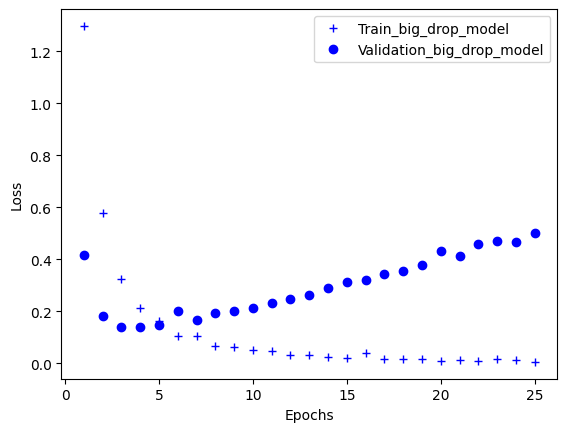

In [30]:
epochs = range(1, 26)
train_loss = bigger_hist_drop.history['loss']
bigger_model_drop_val_loss = bigger_hist_drop.history['val_loss']

# b+ is for "blue cross"
plt.plot(epochs, train_loss, 'b+', label='Train_big_drop_model')
# "bo" is for "blue dot"
plt.plot(epochs, bigger_model_drop_val_loss, 'bo', label='Validation_big_drop_model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

As we can see with drop out the model overfits a lot, so in this case dropout is not a good option of regularization.

Let's try dropout with L2 regularization and see how it works.

In [31]:
bigger_model_l2_drop = keras.Sequential([
    layers.Dense(256, kernel_regularizer=regularizers.l2(0.001), activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, kernel_regularizer=regularizers.l2(0.001), activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(64, kernel_regularizer=regularizers.l2(0.001), activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(32, kernel_regularizer=regularizers.l2(0.001), activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(9, activation="softmax")
])

In [32]:
#Compile the model
bigger_model_l2_drop.compile(optimizer="rmsprop",
              loss="categorical_crossentropy", # multiclase
              metrics=["accuracy"])

In [33]:
bigger_hist_l2_drop = bigger_model_l2_drop.fit(
    train_mat,
    train_labels_encoded,
    epochs=40,
    batch_size=512,
    validation_data=(X_val_from_test, y_val_from_test))

Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.1804 - loss: 3.2088 - val_accuracy: 0.7615 - val_loss: 1.8511
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4221 - loss: 2.2904 - val_accuracy: 0.8541 - val_loss: 1.2684
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5901 - loss: 1.8679 - val_accuracy: 0.8839 - val_loss: 1.0627
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6883 - loss: 1.5533 - val_accuracy: 0.9119 - val_loss: 0.9504
Epoch 5/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7716 - loss: 1.3157 - val_accuracy: 0.9322 - val_loss: 0.8978
Epoch 6/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8285 - loss: 1.1507 - val_accuracy: 0.9354 - val_loss: 0.8728
Epoch 7/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8616 - loss: 1.0167 - val_accuracy: 0.9422 - val_loss: 0.8411
Epoch 8/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8838 - loss: 0.9372 - val_accuracy: 0.9435 - v

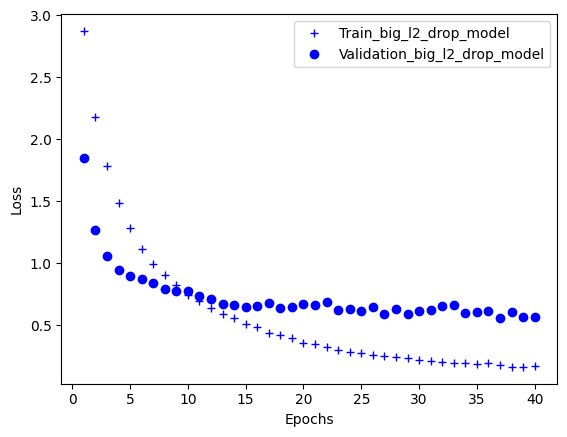

In [34]:
epochs = range(1, 41)
train_loss = bigger_hist_l2_drop.history['loss']
bigger_model_l2_drop_val_loss = bigger_hist_l2_drop.history['val_loss']

# b+ is for "blue cross"
plt.plot(epochs, train_loss, 'b+', label='Train_big_l2_drop_model')
# "bo" is for "blue dot"
plt.plot(epochs, bigger_model_l2_drop_val_loss, 'bo', label='Validation_big_l2_drop_model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

As we can see it performs well but no as well as only with L2 regularization only. We can also see that it learns slower due to the regularization parameters.

Let's try L1 just to check if the model performs better with this regularization

In [35]:
bigger_model_l1 = keras.Sequential([
    layers.Dense(256, kernel_regularizer=regularizers.l1(0.001), activation="relu"),
    layers.Dense(128, kernel_regularizer=regularizers.l1(0.001), activation="relu"),
    layers.Dense(64, kernel_regularizer=regularizers.l1(0.001), activation="relu"),
    layers.Dense(32, kernel_regularizer=regularizers.l1(0.001), activation="relu"),
    layers.Dense(9, activation="softmax")
])

In [36]:
#Compile the model
bigger_model_l1.compile(optimizer="rmsprop",
              loss="categorical_crossentropy", # multiclase
              metrics=["accuracy"])

In [37]:
bigger_hist_l1 = bigger_model_l1.fit(
    train_mat,
    train_labels_encoded,
    epochs=35,
    batch_size=512,
    validation_data=(X_val_from_test, y_val_from_test))

Epoch 1/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6304 - loss: 12.6343 - val_accuracy: 0.9571 - val_loss: 8.9425
Epoch 2/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9498 - loss: 8.0981 - val_accuracy: 0.9675 - val_loss: 6.0479
Epoch 3/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9504 - loss: 5.4637 - val_accuracy: 0.9435 - val_loss: 4.1597
Epoch 4/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9751 - loss: 3.6092 - val_accuracy: 0.9670 - val_loss: 2.8689
Epoch 5/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9716 - loss: 2.5850 - val_accuracy: 0.9747 - val_loss: 2.2700
Epoch 6/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9799 - loss: 2.0241 - val_accuracy: 0.9729 - val_loss: 1.8704
Epoch 7/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9830 - loss: 1.6560 - val_accuracy: 0.9494 - val_loss: 1.6768
Epoch 8/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9657 - loss: 1.4466 - val_accuracy: 0.9697 - 

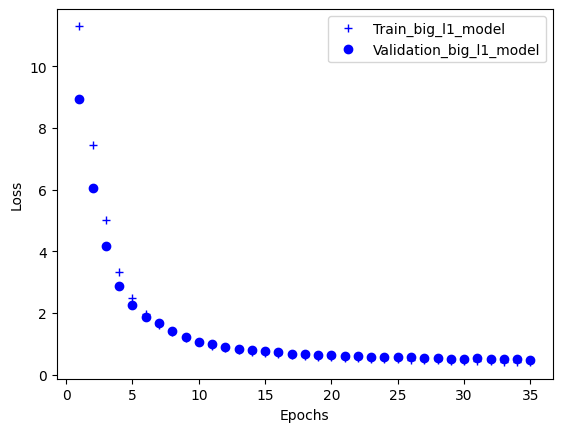

In [38]:
epochs = range(1, 36)
train_loss = bigger_hist_l1.history['loss']
bigger_model_l1_val_loss = bigger_hist_l1.history['val_loss']

# b+ is for "blue cross"
plt.plot(epochs, train_loss, 'b+', label='Train_big_l1_model')
# "bo" is for "blue dot"
plt.plot(epochs, bigger_model_l1_val_loss, 'bo', label='Validation_big_l1_model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

It perfoms really well, I will take the big model wit L1 regularization for doing the final training and test.

## Final model with L1 regularization

In [39]:
bigger_model_l1_final = keras.Sequential([
    layers.Dense(256, kernel_regularizer=regularizers.l1(0.001), activation="relu"),
    layers.Dense(128, kernel_regularizer=regularizers.l1(0.001), activation="relu"),
    layers.Dense(64, kernel_regularizer=regularizers.l1(0.001), activation="relu"),
    layers.Dense(32, kernel_regularizer=regularizers.l1(0.001), activation="relu"),
    layers.Dense(9, activation="softmax")
])

In [40]:
#Compile the model
bigger_model_l1_final.compile(optimizer="rmsprop",
              loss="categorical_crossentropy", # multiclase
              metrics=["accuracy"])

In [41]:
bigger_hist_l1_final = bigger_model_l1_final.fit(
    train_mat,
    train_labels_encoded,
    epochs=35,
    batch_size=512,
    )

Epoch 1/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6315 - loss: 12.6626
Epoch 2/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9517 - loss: 8.0640
Epoch 3/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9622 - loss: 5.3937
Epoch 4/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9703 - loss: 3.5228
Epoch 5/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9670 - loss: 2.5368
Epoch 6/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9784 - loss: 2.0041
Epoch 7/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9832 - loss: 1.6372
Epoch 8/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9598 - loss: 1.4465
Epoch 9/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9776 - loss: 1.2079
Epoch 10/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9646 - loss: 1.1071
Epoch 11/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9746 - loss: 0.9841
Epoch 12/35
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy

231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 0.9737056112767688
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1172
           1       0.98      0.97      0.97      2183
           2       0.93      0.96      0.95      1066
           3       0.00      0.00      0.00         7
           4       0.92      0.82      0.87        57
           5       0.98      0.99      0.98      2176
           6       0.99      0.88      0.93       355
           7       0.99      1.00      0.99       290
           8       0.99      0.99      0.99        72

    accuracy                           0.97      7378
   macro avg       0.86      0.85      0.85      7378
weighted avg       0.97      0.97      0.97      7378



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


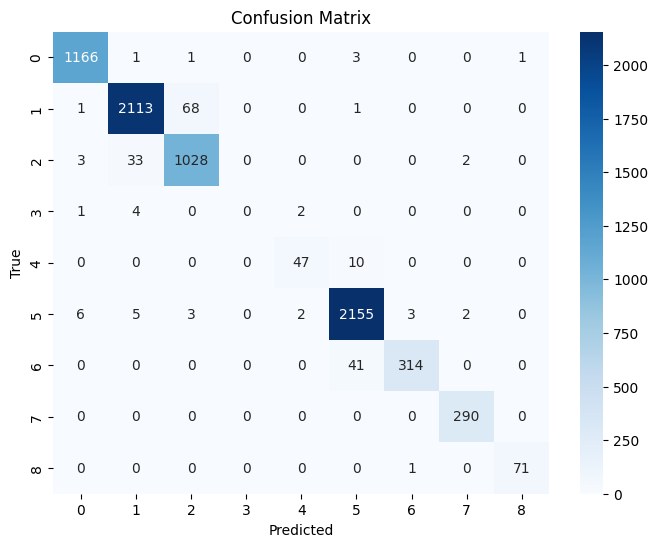

In [44]:
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Predicciones del modelo
y_pred_proba = bigger_model_l1_final.predict(test_mat)
y_pred = np.argmax(y_pred_proba, axis=1)

# Etiquetas verdaderas
y_true = np.argmax(test_labels_encoded, axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_accuracy)
print(classification_report(y_true, y_pred))
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


## Conclusions

Throughout the project, we experimented with several neural network architectures to illustrate underfitting, balanced performance, and overfitting. Smaller models lacked capacity and underfit the data, while larger networks overfitted quickly. After comparing these behaviors, we selected a model with L1 regularization, which provided the best balance between flexibility and generalization.
The final model achieved a test accuracy of 0.97, with most classes reaching precision and recall above 0.95. Only extremely small classes, such as class 3 with just 7 samples, showed poor performance an expected limitation caused by class imbalance rather than model deficiency. The confusion matrix also confirmed that the model makes very few cross-class errors, concentrating predictions on the diagonal.
Overall, the L1-regularized model delivered robust and stable performance, avoiding both underfitting and overfitting while achieving strong generalization across the test set.